# Triage eval: analysis

Reads `eval/results/runs.jsonl` and plots the model-comparison metrics. All numbers
come from `eval.metrics`, the same module the `report` CLI uses, so nothing here can
disagree with the printed summary.

Needs `pandas` and `matplotlib` (see `eval/requirements-eval.txt`). Run it after a
sweep; it works on partial results too. Launch Jupyter from anywhere inside the
`Claims_agent-v2` repo.

In [1]:
import sys
from pathlib import Path

def _find_repo():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / 'eval' / 'metrics.py').exists():
            return c
    raise RuntimeError('Run this notebook from within the Claims_agent-v2 repo.')

REPO = _find_repo()
sys.path.insert(0, str(REPO))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from eval import metrics

RESULTS = REPO / 'eval' / 'results' / 'runs.jsonl'
runs, errors = metrics.load_all(RESULTS)
summary = metrics.summarize(runs, errors)
print(f'{len(runs)} runs, {len(errors)} errors, {len(summary)} model(s)')
df = pd.DataFrame(runs)
df.head()

60 runs, 0 errors, 1 model(s)


,timestamp,model,scenario_id,title,run,decision,expected,correct,guardrail_violation,policy_verified,...,extracted,structural,structural_ok,latency_s,temperature,llm_calls,input_tokens,output_tokens,code_sha,scenario_set_hash
0,2026-09-17T20:30:02.526005+00:00,openai/gpt-oss-20b,clean_approve,"Clean, valid auto claim",0,APPROVE,[APPROVE],True,False,True,...,"{'policy_number': {'value': 'POL-53276', 'conf...",{},None,11.976,0.1,6,8114,724,8b1f121,d48304b3a4b8
1,2026-09-17T20:31:06.891747+00:00,openai/gpt-oss-20b,clean_approve,"Clean, valid auto claim",1,APPROVE,[APPROVE],True,False,True,...,"{'policy_number': {'value': 'POL-53276', 'conf...",{},None,46.926,0.1,6,8192,874,8b1f121,d48304b3a4b8
2,2026-09-17T20:32:01.573999+00:00,openai/gpt-oss-20b,clean_approve,"Clean, valid auto claim",2,APPROVE,[APPROVE],True,False,True,...,"{'policy_number': {'value': 'POL-53276', 'conf...",{},None,54.670,0.1,6,8192,840,8b1f121,d48304b3a4b8
3,2026-09-17T20:32:59.124014+00:00,openai/gpt-oss-20b,clean_approve,"Clean, valid auto claim",3,APPROVE,[APPROVE],True,False,True,...,"{'policy_number': {'value': 'POL-53276', 'conf...",{},None,57.538,0.1,6,8186,757,8b1f121,d48304b3a4b8
4,2026-09-17T20:33:54.016344+00:00,openai/gpt-oss-20b,clean_approve,"Clean, valid auto claim",4,APPROVE,[APPROVE],True,False,True,...,"{'policy_number': {'value': 'POL-53276', 'conf...",{},None,54.880,0.1,6,8182,708,8b1f121,d48304b3a4b8


## Summary table

In [2]:
rows = []
for m, s in summary.items():
    rows.append({
        'model': m, 'n': s['runs'],
        'accuracy': s['accuracy'], 'ci_low': s['accuracy_ci'][0], 'ci_high': s['accuracy_ci'][1],
        'stability': s['stability'], 'false_approval_rate': s['false_approval_rate'],
        'guardrail_violations': s['guardrail_violations'], 'completion': s['completion_rate'],
        'mean_latency_s': s['mean_latency_s'], 'mean_cost_usd': s['mean_cost_usd'],
    })
sumdf = pd.DataFrame(rows).sort_values('accuracy', ascending=False).reset_index(drop=True)
sumdf

,model,n,accuracy,ci_low,ci_high,stability,false_approval_rate,guardrail_violations,completion,mean_latency_s,mean_cost_usd
0,openai/gpt-oss-20b,60,0.983333,0.911447,0.997052,0.983333,0.0,0,1.0,30.12185,0.001075


## Accuracy with 95% Wilson intervals

If the bars' error ranges overlap, the models are not distinguishable at this n.

These intervals assume every run is an independent observation, which is not true
here: the runs are k repeats of each scenario and are correlated within scenario.
The real intervals are wider, so treating overlap as "not distinguishable" is the
safe direction to be wrong in. The agent-evaluation notebook computes the clustered
version.

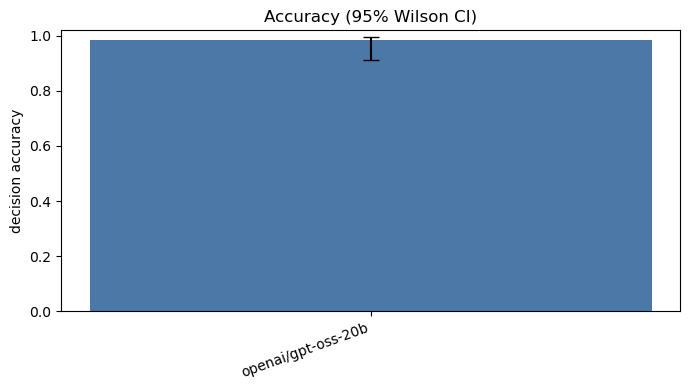

In [3]:
models = list(sumdf['model'])
acc = list(sumdf['accuracy'])
lo = [a - l for a, l in zip(acc, sumdf['ci_low'])]
hi = [h - a for a, h in zip(acc, sumdf['ci_high'])]
plt.figure(figsize=(7, 4))
plt.bar(models, acc, yerr=[lo, hi], capsize=6, color='#4c78a8')
plt.ylim(0, 1.02); plt.ylabel('decision accuracy')
plt.title('Accuracy (95% Wilson CI)')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

## Cost vs accuracy

The actual model-selection trade-off: up-and-to-the-left is better (cheaper, more accurate).

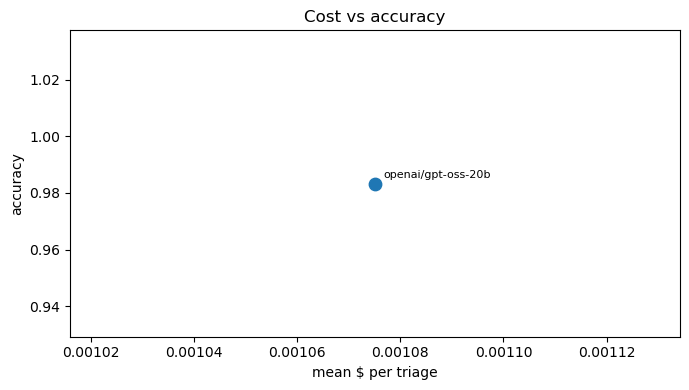

In [4]:
plt.figure(figsize=(7, 4))
for m, s in summary.items():
    if s['mean_cost_usd'] is None:
        continue
    plt.scatter(s['mean_cost_usd'], s['accuracy'], s=80)
    plt.annotate(m, (s['mean_cost_usd'], s['accuracy']),
                 textcoords='offset points', xytext=(6, 4), fontsize=8)
plt.xlabel('mean $ per triage'); plt.ylabel('accuracy')
plt.title('Cost vs accuracy'); plt.tight_layout(); plt.show()

## Latency distribution

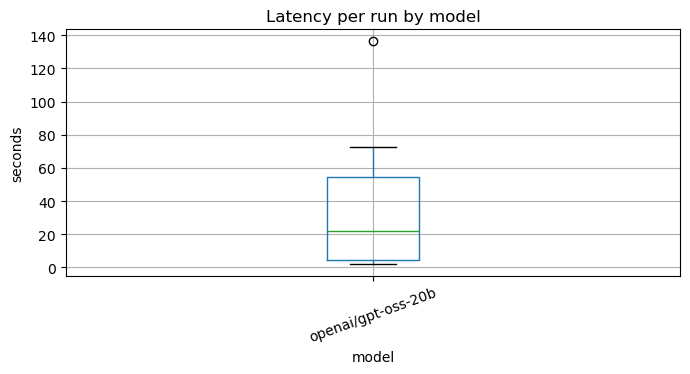

In [5]:
if not df.empty:
    df.boxplot(column='latency_s', by='model', figsize=(7, 4), rot=20)
    plt.suptitle(''); plt.title('Latency per run by model')
    plt.ylabel('seconds'); plt.tight_layout(); plt.show()

## Confusion matrices

Rows are the expected (primary) decision, columns the predicted one. Off-diagonal
mass in the approve column against a non-approve row is the expensive kind of error.

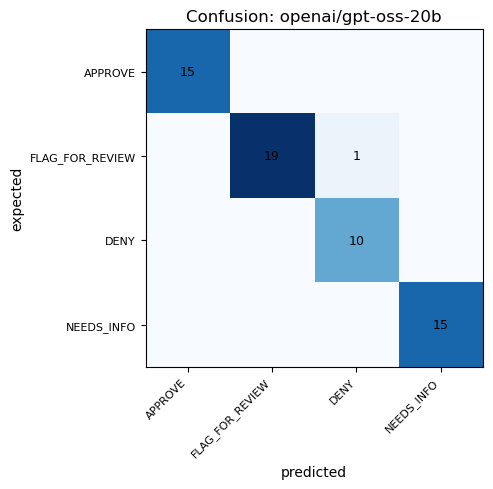

In [6]:
labels = metrics.DECISIONS
for m in summary:
    mat = metrics.confusion(runs, m)
    M = np.array([[mat.get((g, p), 0) for p in labels] for g in labels])
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(M, cmap='Blues')
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
    for i in range(len(labels)):
        for j in range(len(labels)):
            if M[i, j]:
                ax.text(j, i, M[i, j], ha='center', va='center', fontsize=9)
    ax.set_title(f'Confusion: {m}'); ax.set_xlabel('predicted'); ax.set_ylabel('expected')
    plt.tight_layout(); plt.show()

## Per-scenario modal decision grid

In [7]:
if not df.empty:
    grid = (df.groupby(['scenario_id', 'model'])['decision']
              .agg(lambda s: s.mode().iat[0]).unstack('model'))
    display(grid)

model,openai/gpt-oss-20b
scenario_id,
clean_approve,APPROVE
confirmation_resolves,APPROVE
expired_policy,DENY
fraud_new_customer,FLAG_FOR_REVIEW
missing_policy,NEEDS_INFO
name_mismatch,FLAG_FOR_REVIEW
near_limit,FLAG_FOR_REVIEW
non_claim,DENY
ocr_recovery,APPROVE
